# ggh4x — Facets

A Python port of the R **ggh4x** facet toolkit, built on `ggplot2_py`. This notebook reproduces the *Facets* vignette: extended grid/wrap facets, nested strips, manual layouts, per-strip theming, per-panel scales, and forced panel sizes. Plots render inline via each plot object's `_repr_png_`.

In [1]:
import numpy as np, pandas as pd
from ggplot2_py import (ggplot, aes, geom_point, labs, theme,
                        element_line, element_blank, facet_wrap, vars)
import ggh4x
from ggh4x import (facet_wrap2, facet_grid2, facet_nested, facet_nested_wrap,
                   facet_manual, strip_vanilla, strip_themed, strip_nested,
                   elem_list_rect, elem_list_text, facetted_pos_scales,
                   scale_x_facet, force_panelsizes)
from ggh4x._datasets import mpg, load_iris
from grid_py import Unit
def unit(x, u): return Unit(x if isinstance(x, list) else [x], "inches" if u == "in" else u)

# Base plot used throughout (mpg dataset). colour is decorative; legend hidden.
mpg = mpg.copy(); mpg["cyl_f"] = mpg["cyl"].astype("category")
p = (ggplot(mpg, aes("displ", "hwy", colour="cyl_f")) + geom_point()
     + labs(x="Engine displacement", y="Highway miles per gallon")
     + theme(legend_position="none"))

# Iris with a hierarchical "Nester" grouping for the nested-facet examples.
iris = load_iris()
iris["Nester"] = np.where(iris["Species"] == "setosa", "Short Leaves", "Long Leaves")
iris_plot = ggplot(iris, aes("Sepal.Width", "Sepal.Length")) + geom_point()

## Extended wrap facets — `facet_wrap2`

`facet_wrap2()` mirrors `facet_wrap()` by default, but can draw axes at inner panels (`axes=`) and keep ticks while dropping labels (`remove_labels=`).

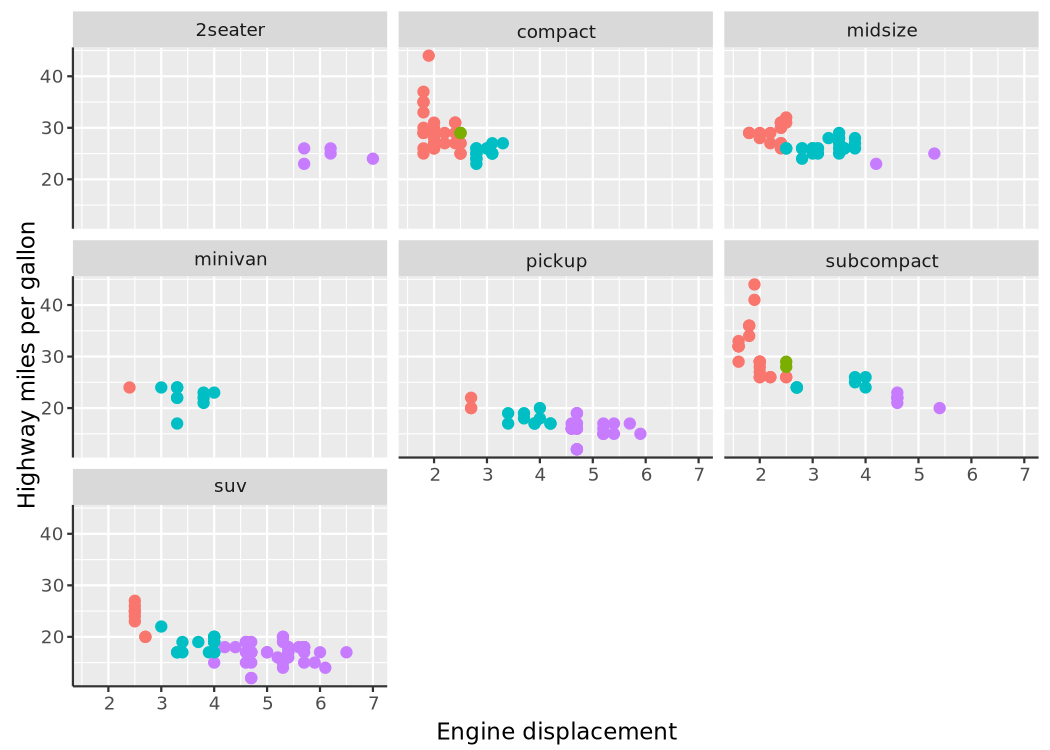

In [2]:
p + facet_wrap2(vars("class"))

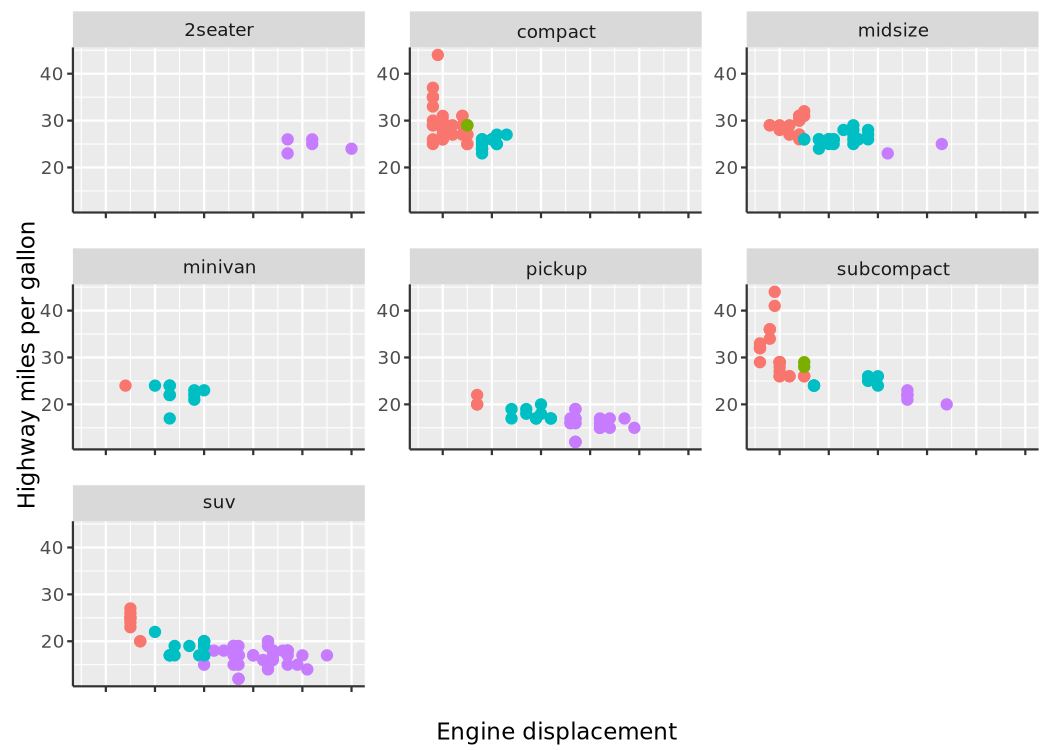

In [3]:
# Draw all inner axes, but remove inner x-axis labels (keep ticks)
p + facet_wrap2(vars("class"), axes="all", remove_labels="x")

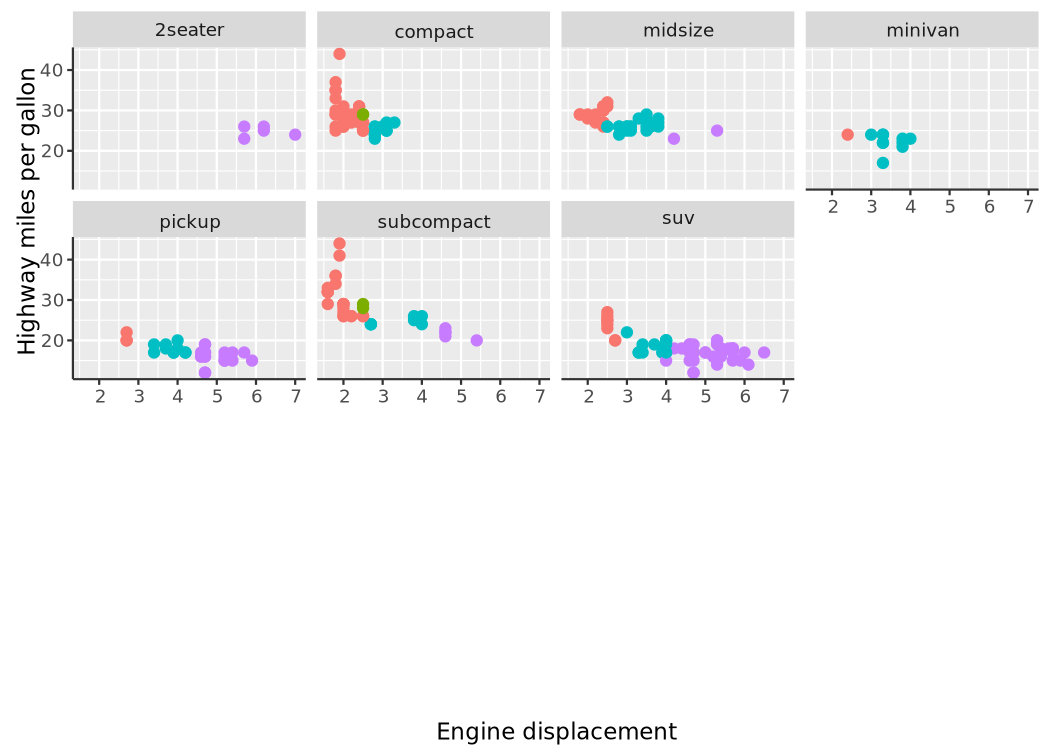

In [4]:
# Force an exact nrow/ncol grid (do not trim blank cells)
p + facet_wrap2(vars("class"), nrow=4, ncol=4, trim_blank=False)

## Extended grid facets — `facet_grid2`

Like `facet_grid()` plus the same axis options, and **independent** scales (free *within* rows/cols of the grid, not just between them).

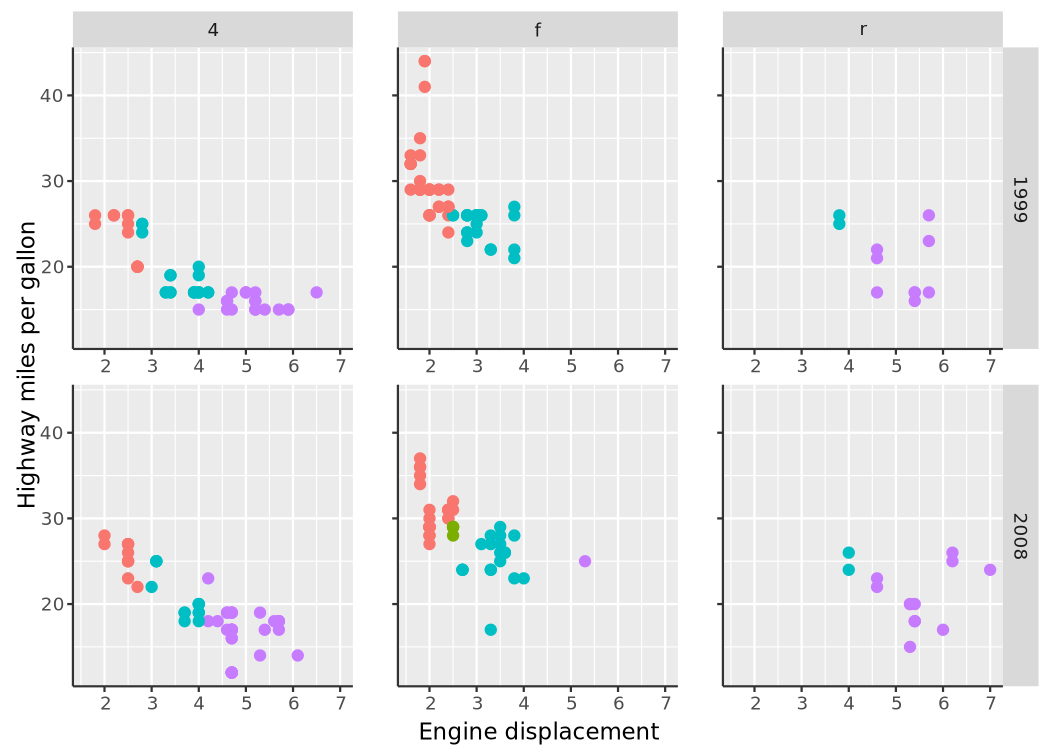

In [5]:
p + facet_grid2(vars("year"), vars("drv"), axes="all", remove_labels="y")

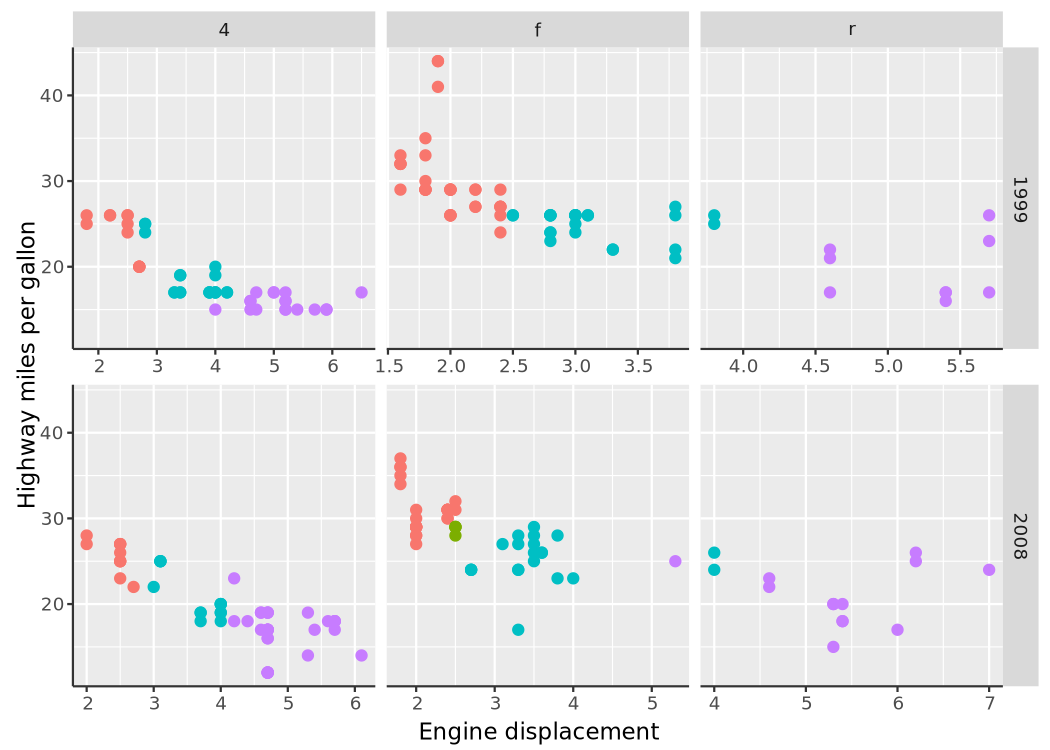

In [6]:
# Independent x scales per panel
p + facet_grid2(vars("year"), vars("drv"), scales="free_x", independent="x")

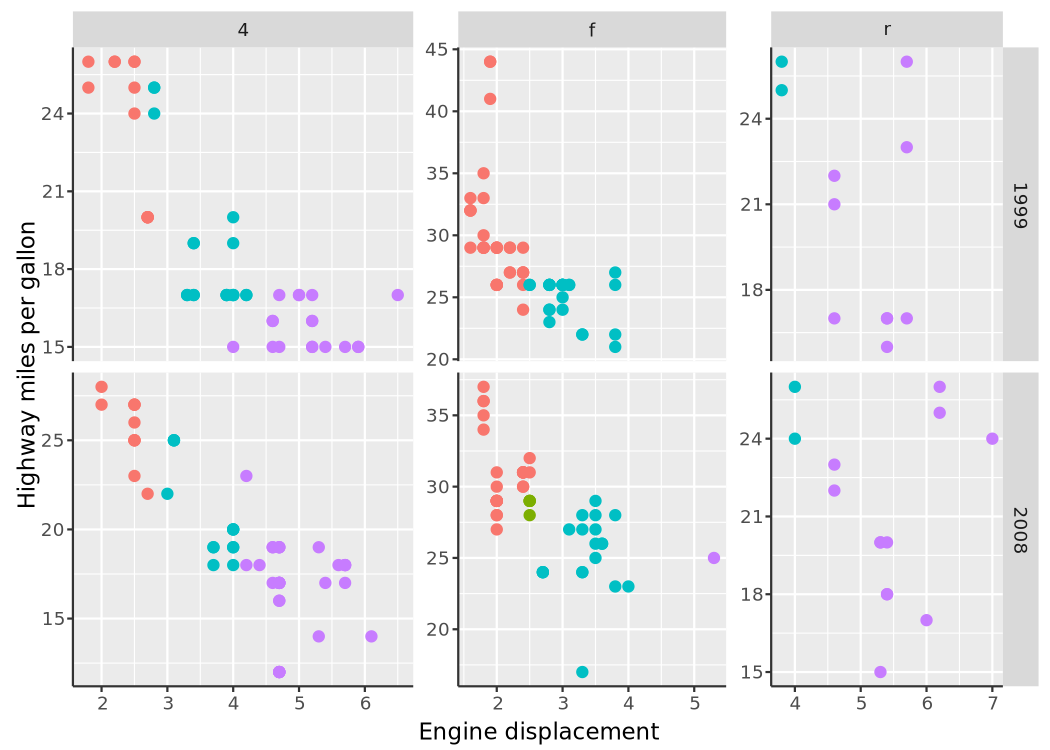

In [7]:
# Independent in one dimension, free space in the other
p + facet_grid2(vars("year"), vars("drv"), scales="free", independent="y", space="free_x")

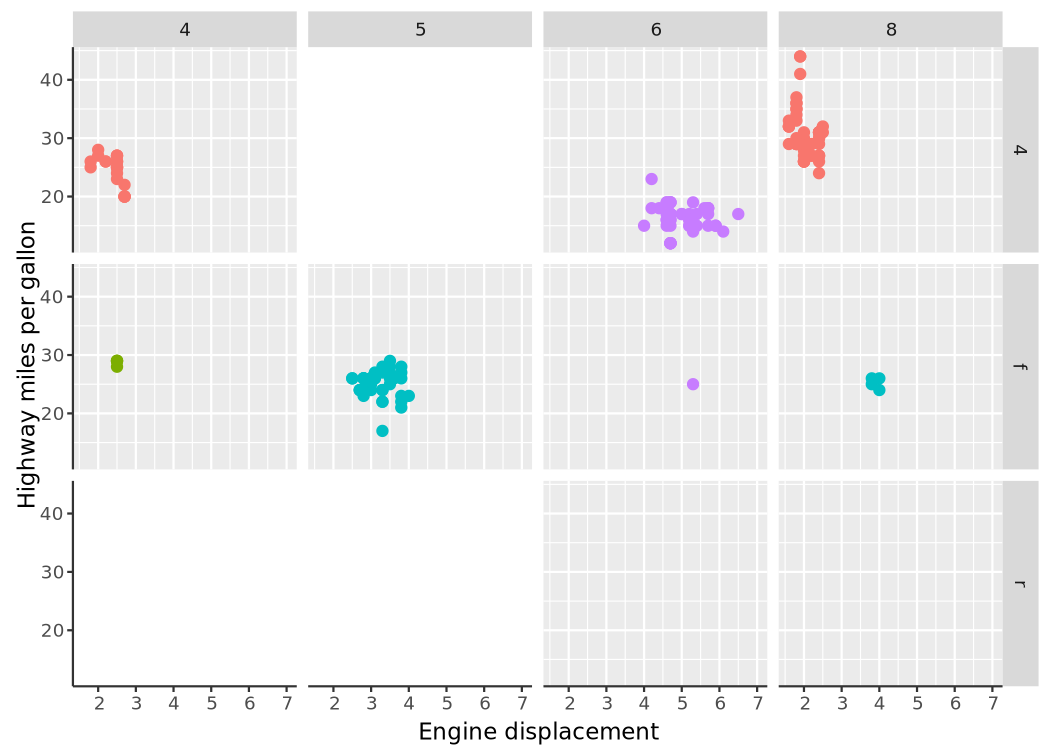

In [8]:
# Hide empty intersections
p + facet_grid2(vars("drv"), vars("cyl"), render_empty=False)

## Nested facets — `facet_nested`

Outer strips spanning inner strips when they share a category (hierarchical facets). Here Iris species are grouped into short/long-leaved nesters.

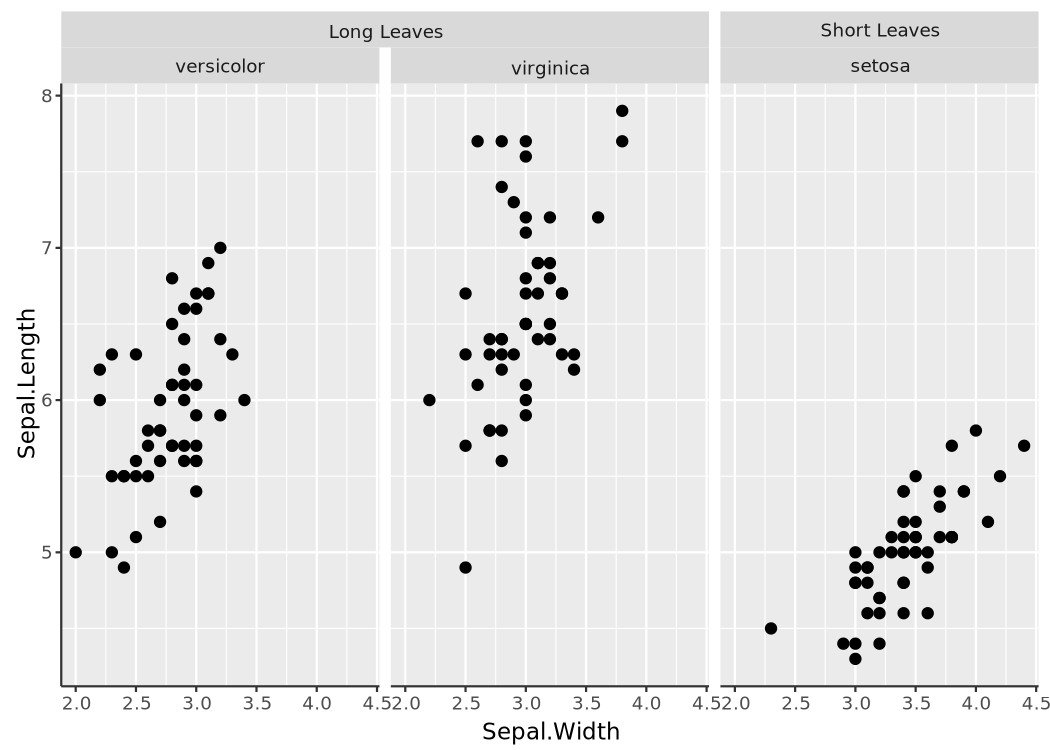

In [9]:
iris_plot + facet_nested(cols=vars("Nester", "Species"))

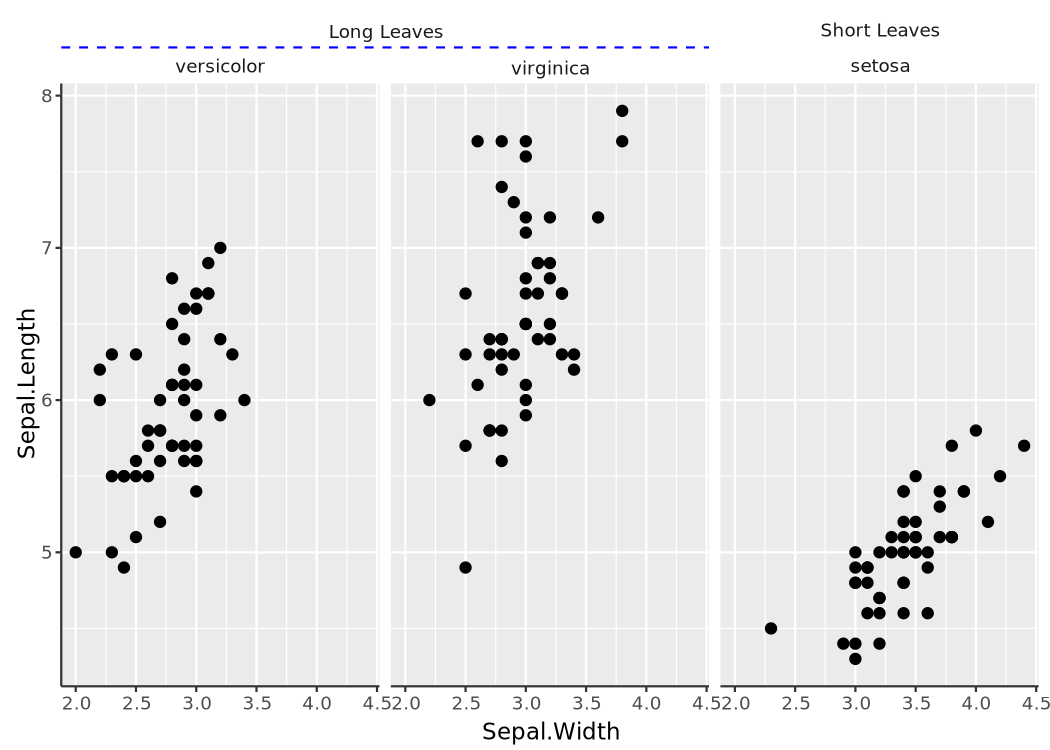

In [10]:
# Nesting line (inherits the ggh4x.facet.nestline theme element)
iris_plot + facet_nested(cols=vars("Nester", "Species"), nest_line=element_line(linetype=2)) \
    + theme(strip_background=element_blank(), ggh4x_facet_nestline=element_line(colour="blue"))

### Wrap variant — `facet_nested_wrap`

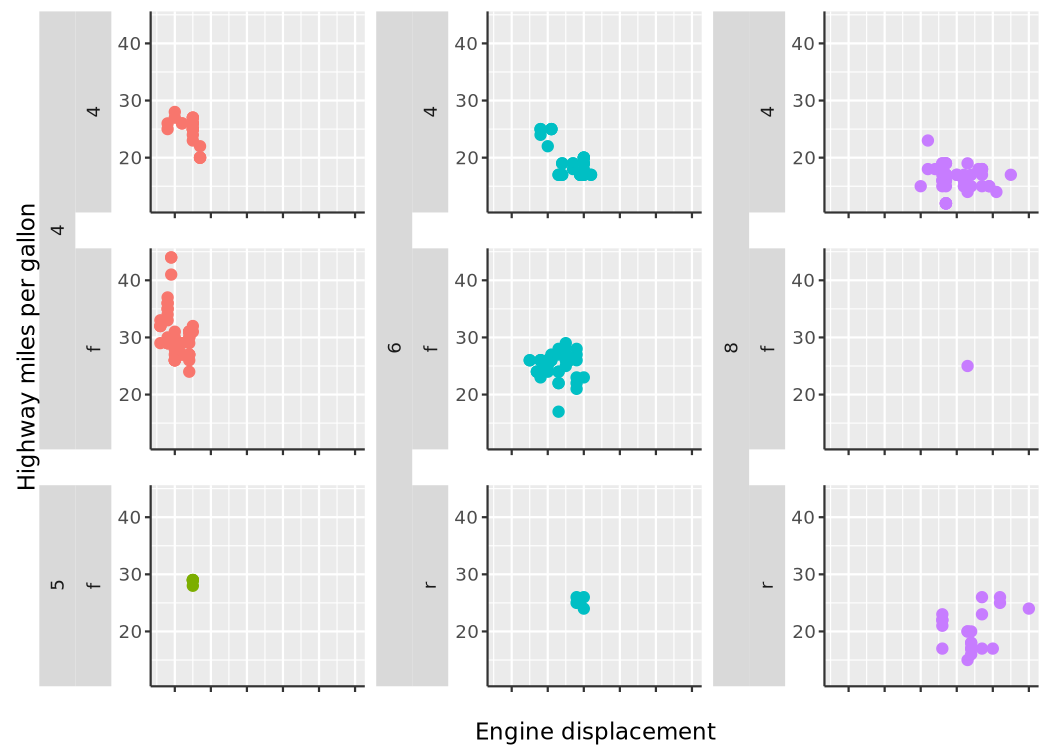

In [11]:
p + facet_nested_wrap(vars("cyl", "drv"), dir="v", strip_position="left", axes="all", remove_labels="x") \
    + theme(strip_placement="outside")

## Manual facets — `facet_manual`

A `layout()`-style design where a single panel may span multiple cells. The base-R `layout()` motivation (a non-ggplot example) is omitted here. The design is a matrix or a character string (`#` = empty cell).

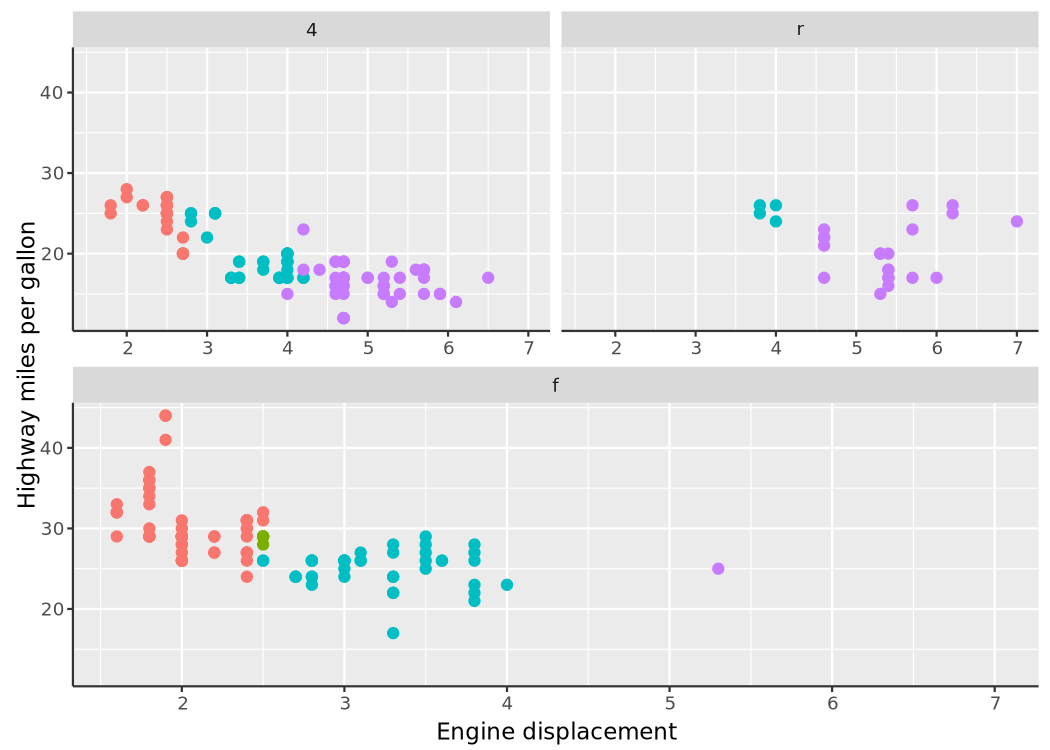

In [12]:
p + facet_manual(vars("drv"), design=np.array([[1, 3], [2, 2]]))

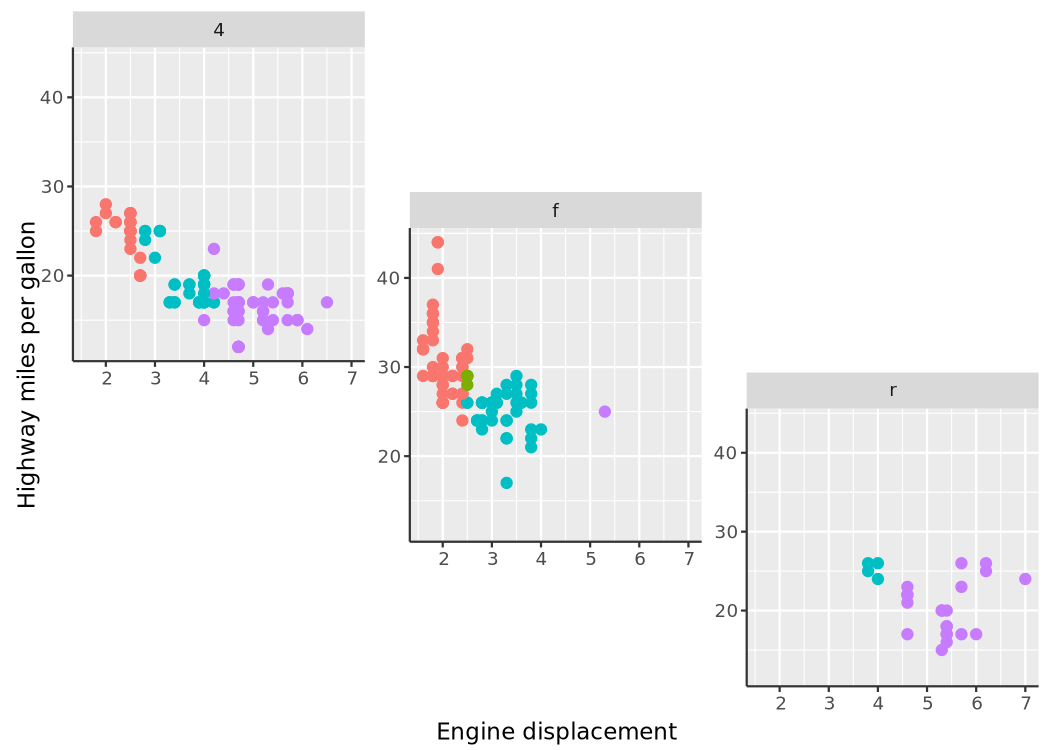

In [13]:
design = """
  A##
  AB#
  #BC
  ##C
"""
p + facet_manual(vars("drv"), design=design)

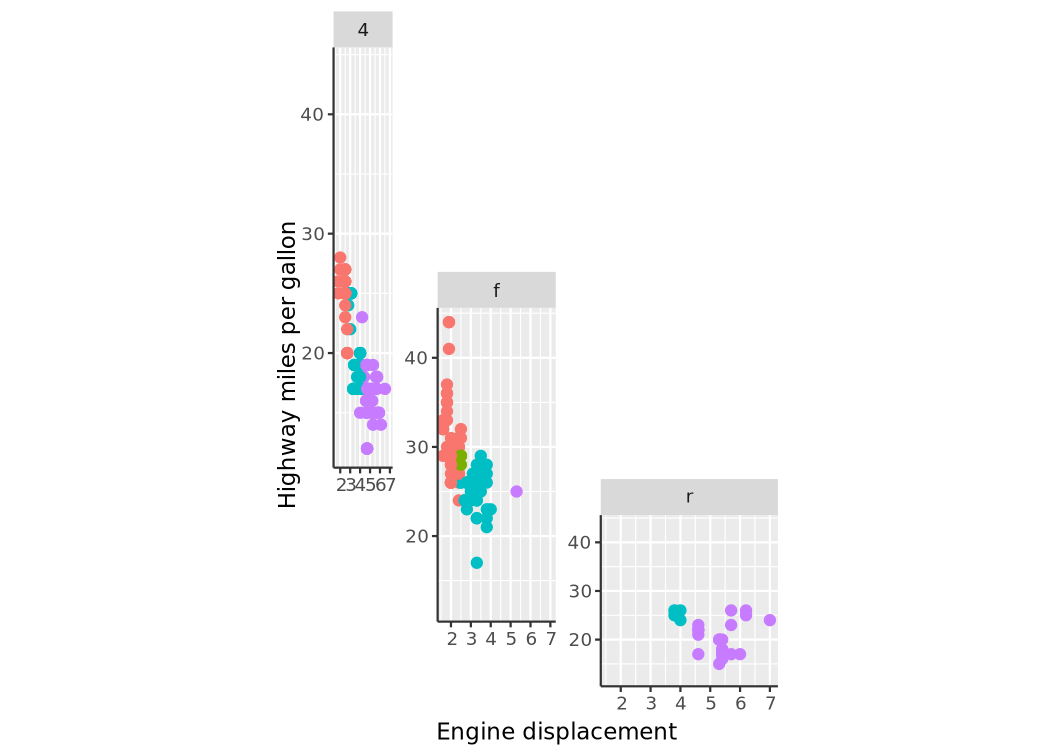

In [14]:
# Relative heights + absolute (cm) widths for the design cells
p + facet_manual(vars("drv"), design=design, heights=[4, 3, 2, 1], widths=unit([1, 2, 3], "cm"))

## Strips

In ggh4x strips are decoupled from facets: every facet takes a `strip=` object from the `strip_*()` family. `strip_vanilla()` (the default) adds `clip` and `size` controls.

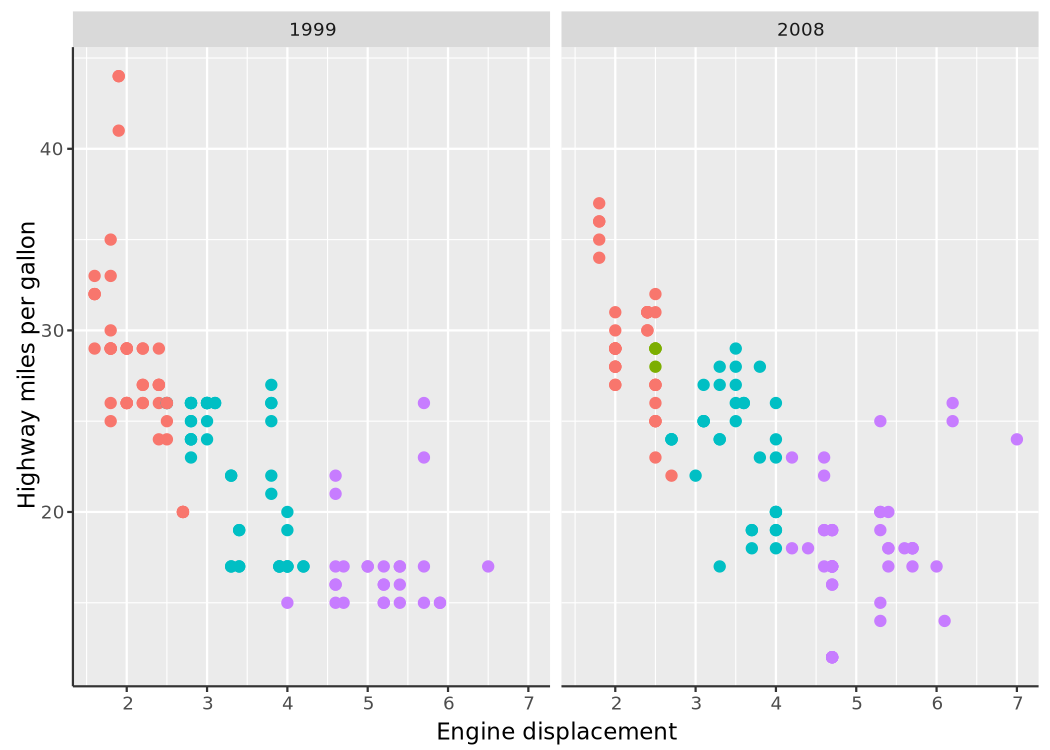

In [15]:
p + facet_wrap2(vars("year"), strip=strip_vanilla(clip="off"))

### Themed strips — per-strip background/text

`strip_themed()` sets `strip.text`/`strip.background` per label or per layer. `elem_list_rect()` / `elem_list_text()` build the element lists concisely.

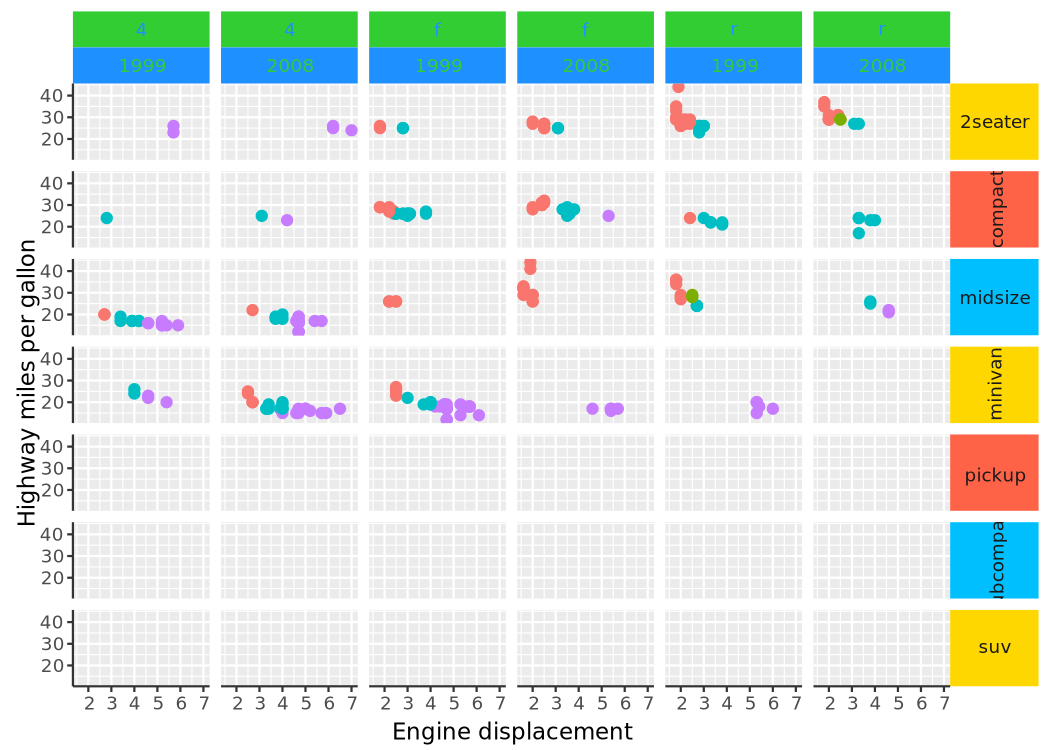

In [16]:
p + facet_grid2(vars("class"), vars("drv", "year"), strip=strip_themed(
    background_x=elem_list_rect(fill=["limegreen", "dodgerblue"]),
    text_x=elem_list_text(colour=["dodgerblue", "limegreen"]), by_layer_x=True,
    background_y=elem_list_rect(fill=["gold", "tomato", "deepskyblue"]),
    text_y=elem_list_text(angle=[0, 90]), by_layer_y=False))

### Nested strips — merge equal adjacent labels

`strip_nested()` merges strips sharing a label at the same layer (default for the nested facets). `bleed` controls merging across differing higher layers.

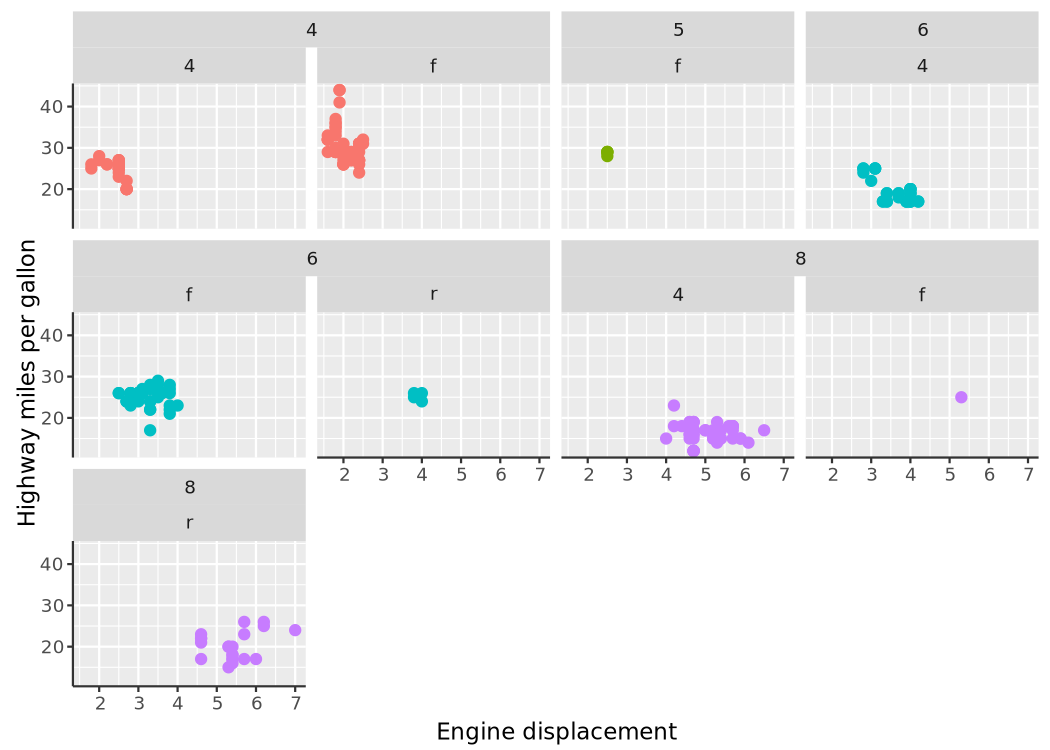

In [17]:
p + facet_wrap2(vars("cyl", "drv"), ncol=4, strip=strip_nested(bleed=False))

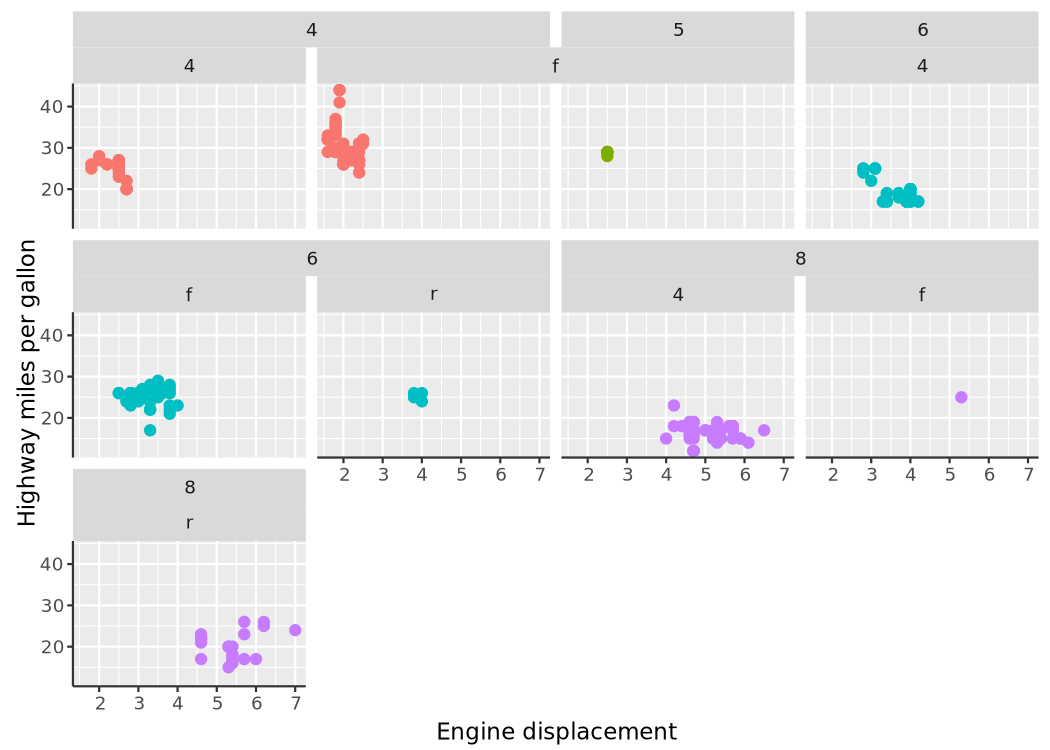

In [18]:
p + facet_wrap2(vars("cyl", "drv"), ncol=4, strip=strip_nested(bleed=True))

## Per-panel position scales

`facetted_pos_scales()` / `scale_x_facet()` vary breaks, limits, labels and transforms per panel (requires free scales).

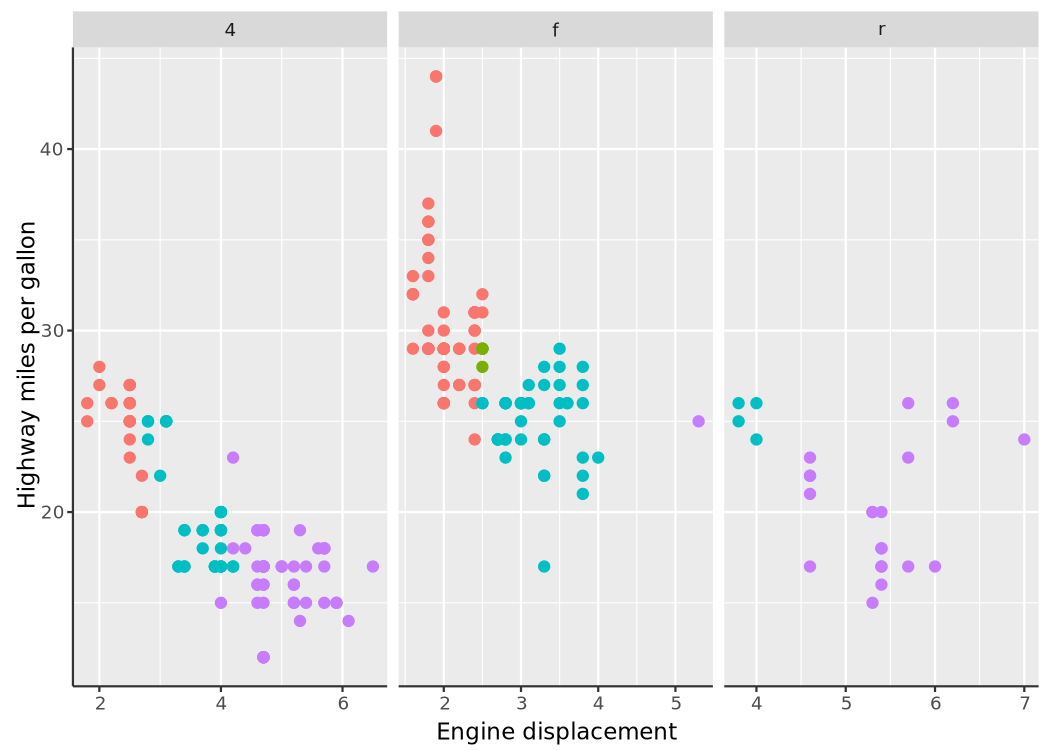

In [19]:
# Per-panel x scales via scale_x_facet (predicate on the layout: COL==1)
p + facet_grid2(cols=vars("drv"), scales="free_x") + scale_x_facet(lambda d: d["COL"] == 1, breaks=[2, 4, 6])

## Panel sizes — `force_panelsizes`

Set absolute or relative panel sizes, overriding aspect-ratio / `space="free"`. Add it *after* the facet.

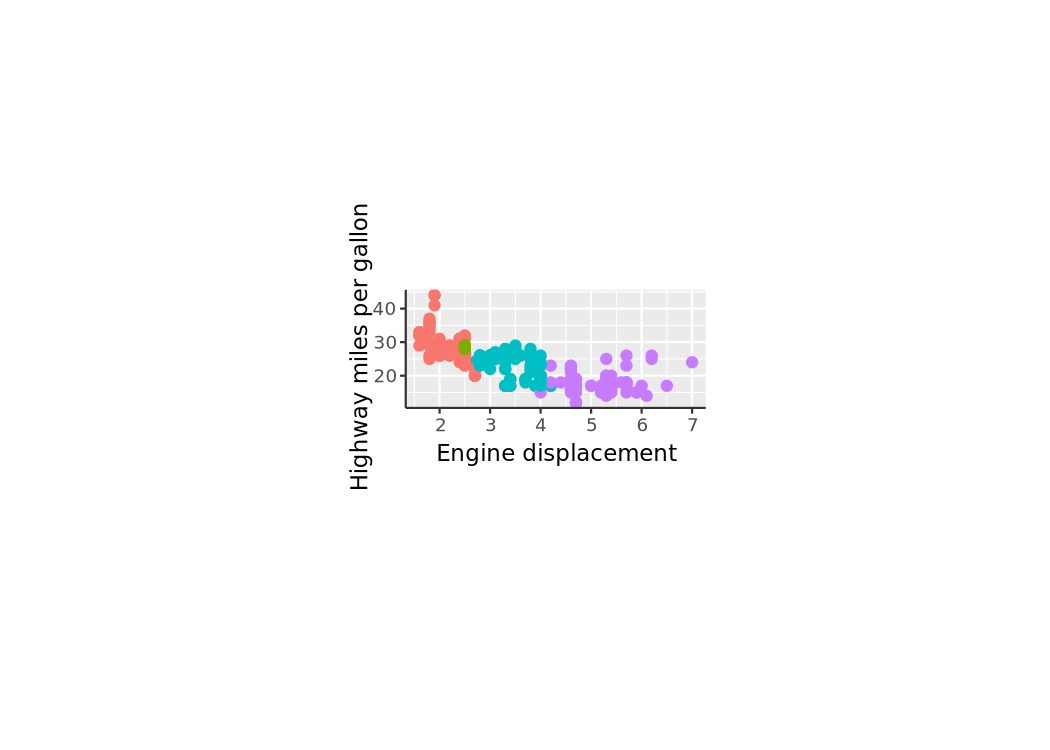

In [20]:
# Absolute sizes
p + force_panelsizes(rows=unit(2, "cm"), cols=unit(2, "in"))

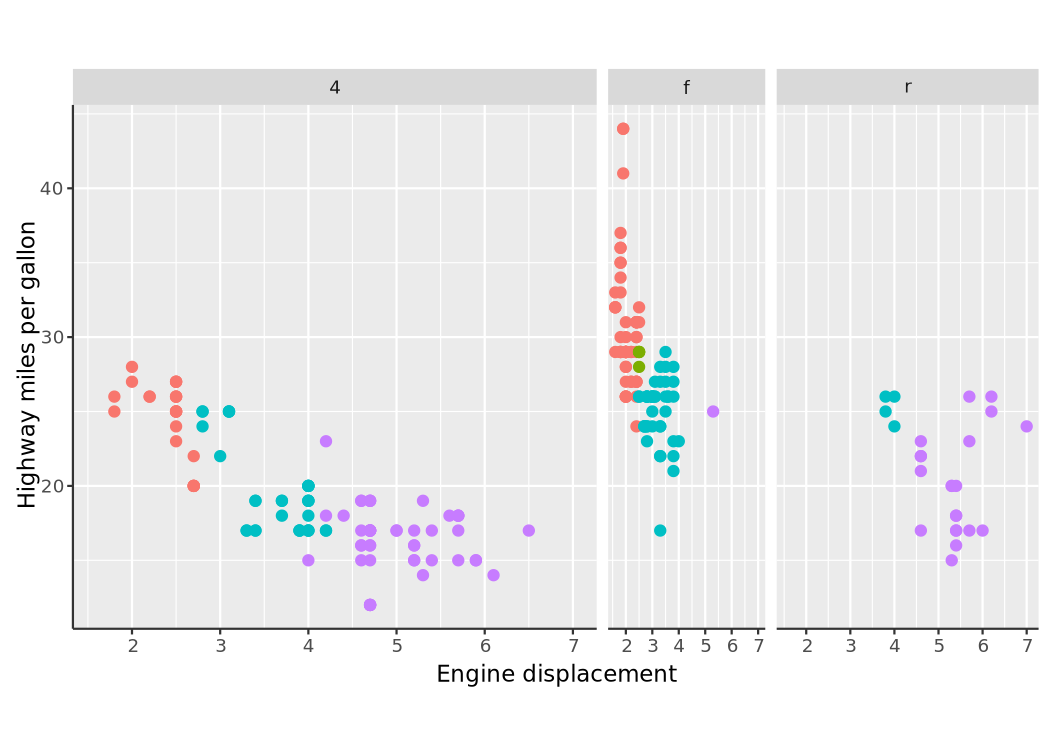

In [21]:
# Relative sizes with respect=True (rows/cols relative to each other)
p + facet_grid2(cols=vars("drv")) + force_panelsizes(cols=[1, 0.3, 0.5], rows=[1], respect=True)